In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import pandas as pd
from pathlib import Path
import pdfplumber
import polars as pl
import re
from shapely.geometry import Point
from sqlalchemy import create_engine
import warnings
import yaml

In [2]:
warnings.filterwarnings("ignore")

DATA_RAW   = Path("../Data/Raw")
DATA_CLEAN = Path("../Data/Clean")
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

In [3]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

## Data cleaning

### First dataset
Meijer2021_midpoint_emisions as rivers_with_countries

1. load & check

In [4]:
rivers = gpd.read_file(config["input_data"]["file1"])
rivers.head()

,dots_exten,geometry
0,0.164904,POINT (168.79792 -46.58083)
1,0.124932,POINT (168.34875 -46.44708)
2,1.213370,POINT (168.33708 -46.41875)
3,0.121138,POINT (168.02125 -46.35792)
4,0.197533,POINT (169.81125 -46.34375)


Let's check out this data set and see what need to be cleaned 

In [5]:
print(rivers.columns.tolist())
print(rivers.shape)
print(rivers.crs)

['dots_exten', 'geometry']
(31819, 2)
EPSG:4326


In [6]:
rivers.describe

<bound method NDFrame.describe of        dots_exten                     geometry
0        0.164904  POINT (168.79792 -46.58083)
1        0.124932  POINT (168.34875 -46.44708)
2        1.213370  POINT (168.33708 -46.41875)
3        0.121138  POINT (168.02125 -46.35792)
4        0.197533  POINT (169.81125 -46.34375)
...           ...                          ...
31814    3.937440   POINT (158.64125 53.02625)
31815    3.821710   POINT (158.48875 53.02958)
31816    9.836130   POINT (158.61292 53.05125)
31817    1.693040   POINT (158.53208 53.06792)
31818    1.886280   POINT (142.96125 53.57292)

[31819 rows x 2 columns]>

In [7]:
rivers.isnull().values.any()

np.False_

### 2. Add country names to the DF &
### 3. rename columns

In [8]:
# Load world map directly from the web
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Run the spatial join with the high-res map
rivers_with_countries = gpd.sjoin(
    rivers,
    world[["geometry", "NAME", "CONTINENT"]],
    how="left",
    predicate="within"
)

rivers_with_countries = rivers_with_countries.rename(columns={
    "dots_exten": "emission",
    "NAME": "country",
    "CONTINENT": "continent"
}).drop(columns=["index_right"])

print(f"Unknown after 10m join: {rivers_with_countries['country'].isna().sum()}")

Unknown after 10m join: 10986


In [9]:
# Second pass: for still-unknown points, try nearest country with a small buffer
still_unknown = rivers_with_countries[rivers_with_countries["country"].isna()].drop(columns=["country", "continent"])

world_buffered = world.copy()
world_buffered["geometry"] = world.geometry.buffer(0.05)

filled = gpd.sjoin(
    still_unknown,
    world_buffered[["geometry", "NAME", "CONTINENT"]],
    how="left",
    predicate="within"
).rename(columns={"NAME": "country", "CONTINENT": "continent"}).drop(columns=["index_right"])

# Drop duplicates keeping first match, then merge back
filled = filled[~filled.index.duplicated(keep="first")]

rivers_with_countries.update(filled[["country", "continent"]])

print(f"Still unknown after buffer: {rivers_with_countries['country'].isna().sum()}")

Still unknown after buffer: 5954


In [10]:
# First pass - 10m resolution spatial join
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip")

rivers_with_countries = gpd.sjoin(
    rivers,
    world[["geometry", "NAME", "CONTINENT"]],
    how="left",
    predicate="within"
).rename(columns={
    "dots_exten": "emission",
    "NAME": "country",
    "CONTINENT": "continent"
}).drop(columns=["index_right"])

print(f"Unknown after 10m join: {rivers_with_countries['country'].isna().sum()}")

# Second pass - progressive buffer
for buffer_size in [0.1, 0.25, 0.5, 1.0]:
    still_unknown = rivers_with_countries[rivers_with_countries["country"].isna()].drop(columns=["country", "continent"])
    
    if len(still_unknown) == 0:
        break
    
    world_buffered = world.copy()
    world_buffered["geometry"] = world.geometry.buffer(buffer_size)
    
    filled = gpd.sjoin(
        still_unknown,
        world_buffered[["geometry", "NAME", "CONTINENT"]],
        how="left",
        predicate="within"
    ).rename(columns={"NAME": "country", "CONTINENT": "continent"}).drop(columns=["index_right"])
    
    filled = filled[~filled.index.duplicated(keep="first")]
    rivers_with_countries.update(filled[["country", "continent"]])
    
    remaining = rivers_with_countries["country"].isna().sum()
    print(f"Buffer {buffer_size}° → {remaining} unknown remaining")

# Fill any truly oceanic points
rivers_with_countries["country"]   = rivers_with_countries["country"].fillna("Ocean")
rivers_with_countries["continent"] = rivers_with_countries["continent"].fillna("Ocean")

Unknown after 10m join: 10795
Buffer 0.1° → 20 unknown remaining
Buffer 0.25° → 4 unknown remaining
Buffer 0.5° → 1 unknown remaining
Buffer 1.0° → 0 unknown remaining


### 4. Check where the unknown countries are

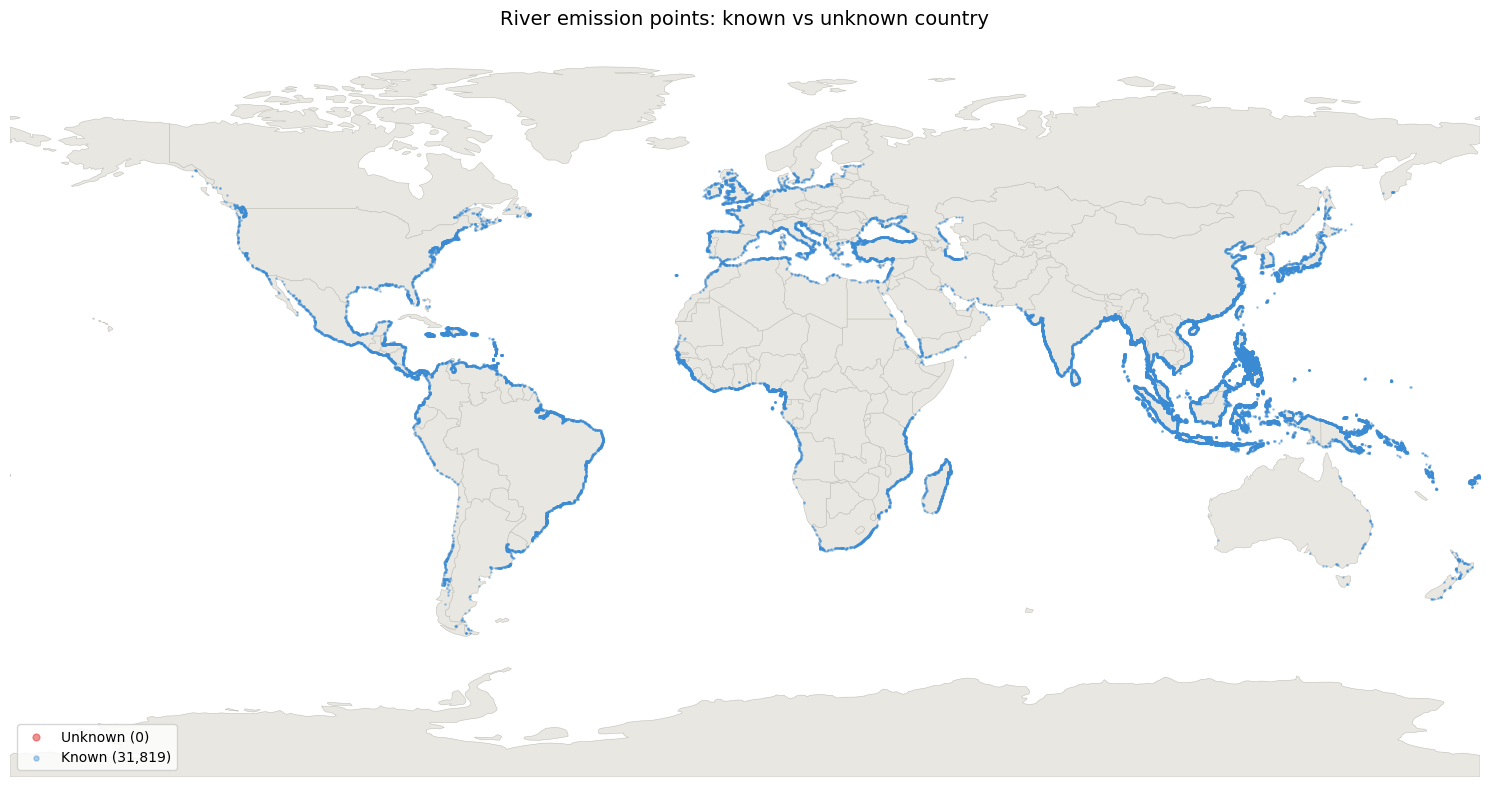

In [11]:
fig, ax = plt.subplots(figsize=(15, 8))

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
world.plot(ax=ax, color='#e8e7e1', edgecolor='#c0bfb8', linewidth=0.4)

known   = rivers_with_countries[rivers_with_countries["country"].notna()]
unknown = rivers_with_countries[rivers_with_countries["country"].isna()]

ax.scatter(
    unknown.geometry.apply(lambda p: p.x),
    unknown.geometry.apply(lambda p: p.y),
    s=1.5, color='#E24B4A', alpha=0.6, label=f'Unknown ({len(unknown):,})'
)
ax.scatter(
    known.geometry.apply(lambda p: p.x),
    known.geometry.apply(lambda p: p.y),
    s=0.8, color='#3B8BD4', alpha=0.4, label=f'Known ({len(known):,})'
)

ax.set_title("River emission points: known vs unknown country", fontsize=14, pad=12)
ax.legend(loc='lower left', markerscale=4, framealpha=0.8)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_axis_off()
plt.tight_layout()
plt.show()

on first run 11.000+ unknown countries --> lets go back and fix that
second run 10.000+ unknown --> go back again and update the code
third try --? 5000_ --> try again
fourth try --> all countries are identified.

### 5. Save

In [12]:
#save clean file
#Go one level up from Notebooks/ to the project root
#project_root = os.path.dirname(os.getcwd())

# Save to the Data/Clean folder
#rivers_with_countries.to_parquet(os.path.join(project_root, "Data", "Clean", "rivers_with_countries.parquet"))

This file is clean.
It has 2 columns: 
dots_exten = plastic emission in metric tons per year.
geometry = exact latituted and longtitude coordinates of each river outlet.
I added countries to the DF to make it clearer to read.

### Second Dataset
global_index_13320_starts_in_jan.cvs as plastic_adrift

1. load and check

In [13]:
plastic_adrift = pl.read_csv(str(config["input_data"]["file2"]))
plastic_adrift.head()

year,month,lat,lng,probability
i64,i64,i64,i64,f64
0,0,-54,324,1.0
0,2,-53,325,0.00101
0,2,-53,326,0.00076
0,2,-53,330,0.00126
0,2,-53,331,0.01357


In [14]:
plastic_adrift.describe

<bound method DataFrame.describe of shape: (57_387, 5)
┌──────┬───────┬─────┬─────┬─────────────┐
│ year ┆ month ┆ lat ┆ lng ┆ probability │
│ ---  ┆ ---   ┆ --- ┆ --- ┆ ---         │
│ i64  ┆ i64   ┆ i64 ┆ i64 ┆ f64         │
╞══════╪═══════╪═════╪═════╪═════════════╡
│ 0    ┆ 0     ┆ -54 ┆ 324 ┆ 1.0         │
│ 0    ┆ 2     ┆ -53 ┆ 325 ┆ 0.00101     │
│ 0    ┆ 2     ┆ -53 ┆ 326 ┆ 0.00076     │
│ 0    ┆ 2     ┆ -53 ┆ 330 ┆ 0.00126     │
│ 0    ┆ 2     ┆ -53 ┆ 331 ┆ 0.01357     │
│ …    ┆ …     ┆ …   ┆ …   ┆ …           │
│ 10   ┆ 0     ┆ -13 ┆ 140 ┆ 0.00064     │
│ 10   ┆ 0     ┆ -13 ┆ 141 ┆ 0.0004      │
│ 10   ┆ 0     ┆ -12 ┆ 140 ┆ 0.00035     │
│ 10   ┆ 0     ┆ -12 ┆ 141 ┆ 0.00029     │
│ 10   ┆ 0     ┆ -11 ┆ 149 ┆ 0.00028     │
└──────┴───────┴─────┴─────┴─────────────┘>

In [15]:
print(plastic_adrift.shape)
print(plastic_adrift.null_count())
print(plastic_adrift["year"].unique())
print(plastic_adrift["month"].unique().sort())
print(plastic_adrift["probability"].describe())

(57387, 5)
shape: (1, 5)
┌──────┬───────┬─────┬─────┬─────────────┐
│ year ┆ month ┆ lat ┆ lng ┆ probability │
│ ---  ┆ ---   ┆ --- ┆ --- ┆ ---         │
│ u32  ┆ u32   ┆ u32 ┆ u32 ┆ u32         │
╞══════╪═══════╪═════╪═════╪═════════════╡
│ 0    ┆ 0     ┆ 0   ┆ 0   ┆ 0           │
└──────┴───────┴─────┴─────┴─────────────┘
shape: (11,)
Series: 'year' [i64]
[
	0
	1
	2
	3
	4
	…
	6
	7
	8
	9
	10
]
shape: (6,)
Series: 'month' [i64]
[
	0
	2
	4
	6
	8
	10
]
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 57387.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.000606 │
│ std        ┆ 0.00464  │
│ min        ┆ 0.00025  │
│ 25%        ┆ 0.0003   │
│ 50%        ┆ 0.00039  │
│ 75%        ┆ 0.00057  │
│ max        ┆ 1.0      │
└────────────┴──────────┘


In [16]:
print(plastic_adrift["lat"].min(), plastic_adrift["lat"].max())
print(plastic_adrift["lng"].min(), plastic_adrift["lng"].max())

-70 1
0 359


2. The lng needs converting to standard -180/180 format so it aligns with the rivers dataset later:

In [17]:
plastic_adrift = plastic_adrift.with_columns([
    (pl.col("year") + 2021).alias("year"),
    pl.when(pl.col("lng") > 180)
      .then(pl.col("lng") - 360)
      .otherwise(pl.col("lng"))
      .alias("lng")
])

print(plastic_adrift["lng"].min(), plastic_adrift["lng"].max())
# Should now be -180 to 180

-179 180


3. save

In [18]:
#plastic_adrift.write_parquet(os.path.join(project_root, "Data", "Clean", "plastic_adrift.parquet"))

This dataset is also clean.
It has 5 columns: 
year relative year index (year 0 = start of simulation)
month: month of the simulation
lat: latitude
lon: longtitude
probability: the probability that plastic is present at that location at that time.

### Third dataset:
marine_microplastics_wgs84_-4941760893681039301.csv as marine_microplastics

In [19]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)


1. load & check

Something is wrong with the data — mixed types or unexpected values in some columns. Loading it with error tolerance first to see what we're working with:

In [20]:
marine_microplastics = pl.read_csv(
    config["input_data"]["file3"],
    ignore_errors=True
)
marine_microplastics.head()

OBJECTID,Latitude (degree),Longitude (degree),Ocean,Region,Subregion,Country,State,Beach Location,Marine Setting,Ocean Bottom Depth (m),Water Sample Depth (m),Sediment Sample Depth (m),Sampling Method,Mesh Size (mm),Transect Number,Sampling Point on Beach,Volunteers Number,Collecting Time (min),Standardized Nurdle Amount,Microplastics Measurement,Unit,Concentration Class Range,Concentration Class,Short Reference,Long Reference,DOI,Organization,Keywords,NCEI Accession Number,NCEI Accession Link,Symbology,GlobalID,Sample Date,x,y
i64,f64,f64,str,str,str,str,str,str,str,str,i64,str,str,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,i64,str,str,str,str,f64,f64
1,45.28,-60.29,"""Atlantic Ocean""",null,null,null,null,null,"""Ocean water""",null,0,null,"""Neuston net""",0.335,null,null,null,null,null,0.0,"""pieces/m3""","""0-0.0005""","""Very Low""","""Law et al.2010""","""Law, K.L., S. Morét-Ferguson, …","""https://doi.org/10.1126/scienc…","""Sea Education Association""","""SEA""",211007,"""https://www.ncei.noaa.gov/acce…","""Ocean Surface, Very Low, 0-0.0…","""2ce1d1d4-4231-4ab8-af74-0b7fbb…","""7/13/1989 12:00:00 AM""",-60.29,45.28
2,40.93,-70.65,"""Atlantic Ocean""",null,null,null,null,null,"""Ocean water""",null,0,null,"""Neuston net""",0.335,null,null,null,null,null,0.002276,"""pieces/m3""","""0.0005-0.005""","""Low""","""Law et al.2010""","""Law, K.L., S. Morét-Ferguson, …","""https://doi.org/10.1126/scienc…","""Sea Education Association""","""SEA""",211007,"""https://www.ncei.noaa.gov/acce…","""Ocean Surface, Low, 0.0005-0.0…","""8e3c8426-5ab0-421e-abb2-6b9019…","""10/12/1989 12:00:00 AM""",-70.65,40.93
3,40.93,-70.65,"""Atlantic Ocean""",null,null,null,null,null,"""Ocean water""",null,0,null,"""Neuston net""",0.335,null,null,null,null,null,0.00432,"""pieces/m3""","""0.0005-0.005""","""Low""","""Law et al.2010""","""Law, K.L., S. Morét-Ferguson, …","""https://doi.org/10.1126/scienc…","""Sea Education Association""","""SEA""",211007,"""https://www.ncei.noaa.gov/acce…","""Ocean Surface, Low, 0.0005-0.0…","""99bda337-9f0c-4f58-9960-8b00c1…","""10/12/1989 12:00:00 AM""",-70.65,40.93
4,40.3,-69.77,"""Atlantic Ocean""",null,null,null,null,null,"""Ocean water""",null,0,null,"""Neuston net""",0.335,null,null,null,null,null,0.0,"""pieces/m3""","""0-0.0005""","""Very Low""","""Law et al.2010""","""Law, K.L., S. Morét-Ferguson, …","""https://doi.org/10.1126/scienc…","""Sea Education Association""","""SEA""",211007,"""https://www.ncei.noaa.gov/acce…","""Ocean Surface, Very Low, 0-0.0…","""1f20e926-2a84-4e42-8478-8a5af5…","""10/12/1989 12:00:00 AM""",-69.77,40.3
5,39.88,-67.15,"""Atlantic Ocean""",null,null,null,null,null,"""Ocean water""",null,0,null,"""Neuston net""",0.335,null,null,null,null,null,0.0,"""pieces/m3""","""0-0.0005""","""Very Low""","""Law et al.2010""","""Law, K.L., S. Morét-Ferguson, …","""https://doi.org/10.1126/scienc…","""Sea Education Association""","""SEA""",211007,"""https://www.ncei.noaa.gov/acce…","""Ocean Surface, Very Low, 0-0.0…","""a0df6bee-9c60-4621-a0bc-3329e3…","""10/15/1989 12:00:00 AM""",-67.15,39.88


In [21]:
marine_microplastics['Keywords'].unique()

Keywords
str
"""Tenerife; Canary Islands"""
"""Ligurian Sea """
"""The Ocean Cleanup Foundation"""
"""SV Sea Dragon"""
"""Mediterranean Sea"""
…
"""Ice breaker Oden"""
"""RV Polarstern; Latitudinal gra…"
"""SV Mir; ORV Alguita; SV Sea Dr…"


In [22]:
print(marine_microplastics.shape)
print(marine_microplastics.dtypes)
print(marine_microplastics.null_count())

(22530, 36)
[Int64, Float64, Float64, String, String, String, String, String, String, String, String, Int64, String, String, Float64, String, String, String, String, String, Float64, String, String, String, String, String, String, String, String, Int64, String, String, String, String, Float64, Float64]
shape: (1, 36)
┌──────────┬──────────┬────────────────────┬───────┬───┬──────────┬─────────────┬─────┬─────┐
│ OBJECTID ┆ Latitude ┆ Longitude (degree) ┆ Ocean ┆ … ┆ GlobalID ┆ Sample Date ┆ x   ┆ y   │
│ ---      ┆ (degree) ┆ ---                ┆ ---   ┆   ┆ ---      ┆ ---         ┆ --- ┆ --- │
│ u32      ┆ ---      ┆ u32                ┆ u32   ┆   ┆ u32      ┆ u32         ┆ u32 ┆ u32 │
│          ┆ u32      ┆                    ┆       ┆   ┆          ┆             ┆     ┆     │
╞══════════╪══════════╪════════════════════╪═══════╪═══╪══════════╪═════════════╪═════╪═════╡
│ 0        ┆ 0        ┆ 0                  ┆ 278   ┆ … ┆ 0        ┆ 0           ┆ 0   ┆ 0   │
└──────────┴──────────┴

A few things stand out:

- 278 nulls in Ocean — worth investigating
- Latitude (degree) and Longitude (degree) — verbose column names, need renaming
- Sample Date — stored as String, needs parsing to a proper date
- 36 columns — likely many irrelevant ones, need to trim down

In [23]:
print(marine_microplastics.columns)

['OBJECTID', 'Latitude (degree)', 'Longitude (degree)', 'Ocean', 'Region', 'Subregion', 'Country', 'State', 'Beach Location', 'Marine Setting', 'Ocean Bottom Depth (m)', 'Water Sample Depth (m)', 'Sediment Sample Depth (m)', 'Sampling Method', 'Mesh Size (mm)', 'Transect Number', 'Sampling Point on Beach', 'Volunteers Number', 'Collecting Time (min)', 'Standardized Nurdle  Amount', 'Microplastics Measurement', 'Unit', 'Concentration Class Range', 'Concentration Class', 'Short Reference', 'Long Reference', 'DOI', 'Organization', 'Keywords', 'NCEI Accession Number', 'NCEI Accession Link', 'Symbology', 'GlobalID', 'Sample Date', 'x', 'y']


In [24]:
print(marine_microplastics.null_count().transpose(include_header=True).sort("column_0", descending=True))

shape: (36, 2)
┌───────────────────────────┬──────────┐
│ column                    ┆ column_0 │
│ ---                       ┆ ---      │
│ str                       ┆ u32      │
╞═══════════════════════════╪══════════╡
│ Transect Number           ┆ 22232    │
│ Ocean Bottom Depth (m)    ┆ 22205    │
│ Sediment Sample Depth (m) ┆ 22144    │
│ Sampling Point on Beach   ┆ 21970    │
│ Subregion                 ┆ 21007    │
│ …                         ┆ …        │
│ Symbology                 ┆ 0        │
│ GlobalID                  ┆ 0        │
│ Sample Date               ┆ 0        │
│ x                         ┆ 0        │
│ y                         ┆ 0        │
└───────────────────────────┴──────────┘


In [25]:
with pl.Config(tbl_rows=-1):
    print(marine_microplastics.null_count().transpose(include_header=True).sort("column_0", descending=True))

shape: (36, 2)
┌─────────────────────────────┬──────────┐
│ column                      ┆ column_0 │
│ ---                         ┆ ---      │
│ str                         ┆ u32      │
╞═════════════════════════════╪══════════╡
│ Transect Number             ┆ 22232    │
│ Ocean Bottom Depth (m)      ┆ 22205    │
│ Sediment Sample Depth (m)   ┆ 22144    │
│ Sampling Point on Beach     ┆ 21970    │
│ Subregion                   ┆ 21007    │
│ Volunteers Number           ┆ 16713    │
│ Collecting Time (min)       ┆ 16713    │
│ Standardized Nurdle  Amount ┆ 16713    │
│ State                       ┆ 16344    │
│ Beach Location              ┆ 16285    │
│ Country                     ┆ 15924    │
│ Region                      ┆ 12268    │
│ Water Sample Depth (m)      ┆ 9961     │
│ Mesh Size (mm)              ┆ 5864     │
│ Microplastics Measurement   ┆ 5817     │
│ Keywords                    ┆ 288      │
│ Ocean                       ┆ 278      │
│ OBJECTID                    ┆ 0      

2. drop columns

Many columns are mostly empty  (Transect Number 22,232 nulls out of 22,530 rows). 
Let's drop anything above 50% null and keep only the analytically useful columns.

In [26]:
marine_microplastics['Keywords'].unique()

Keywords
str
"""Citizen science; Surf board; K…"
"""Chiapas"""
"""RV Celtic Explorer; ROV; Ocean…"
"""Fiji"""
"""Manila Bay"""
…
"""MRV Scotia/MRV Alba na Mara /R…"
"""Ice breaker Oden"""
"""Sail and Explore Association"""


In [27]:
marine_microplastics['Microplastics Measurement'].unique()

Microplastics Measurement
f64
null
0.0
0.000676
0.000832
0.001
…
126000.0
200000.0
352000.0


3. rename columns

In [28]:
cols_to_keep = [
    "OBJECTID",
    "Latitude (degree)",
    "Longitude (degree)",
    "Ocean",
    "Marine Setting",
    "Sampling Method",
    "Mesh Size (mm)",
    "Microplastics Measurement",  
    "Unit",
    "Concentration Class",
    "Sample Date",
    "x",
    "y"
]

marine_microplastics = marine_microplastics.select(cols_to_keep)

# Rename messy column names
marine_microplastics = marine_microplastics.rename({
    "Latitude (degree)": "lat",
    "Longitude (degree)": "lng",
    "Marine Setting": "setting",
    "Sampling Method": "sampling_method",
    "Mesh Size (mm)": "mesh_size_mm",
    "Microplastics Measurement": "microplastics_measurement",
    "Concentration Class": "concentration_class",
    "Sample Date": "sample_date",
    "Ocean": "ocean",
    "Unit": "unit"
})

# change datatype of 'sample_date'
marine_microplastics = marine_microplastics.with_columns(
    pl.col("sample_date").str.to_date(format="%m/%d/%Y %I:%M:%S %p", strict=False)
)

print(marine_microplastics["sample_date"].null_count())
print(marine_microplastics["sample_date"].drop_nulls().head(5))

print(marine_microplastics.shape)
marine_microplastics.head()

0
shape: (5,)
Series: 'sample_date' [date]
[
	1989-07-13
	1989-10-12
	1989-10-12
	1989-10-12
	1989-10-15
]
(22530, 13)


OBJECTID,lat,lng,ocean,setting,sampling_method,mesh_size_mm,microplastics_measurement,unit,concentration_class,sample_date,x,y
i64,f64,f64,str,str,str,f64,f64,str,str,date,f64,f64
1,45.28,-60.29,"""Atlantic Ocean""","""Ocean water""","""Neuston net""",0.335,0.0,"""pieces/m3""","""Very Low""",1989-07-13,-60.29,45.28
2,40.93,-70.65,"""Atlantic Ocean""","""Ocean water""","""Neuston net""",0.335,0.002276,"""pieces/m3""","""Low""",1989-10-12,-70.65,40.93
3,40.93,-70.65,"""Atlantic Ocean""","""Ocean water""","""Neuston net""",0.335,0.00432,"""pieces/m3""","""Low""",1989-10-12,-70.65,40.93
4,40.3,-69.77,"""Atlantic Ocean""","""Ocean water""","""Neuston net""",0.335,0.0,"""pieces/m3""","""Very Low""",1989-10-12,-69.77,40.3
5,39.88,-67.15,"""Atlantic Ocean""","""Ocean water""","""Neuston net""",0.335,0.0,"""pieces/m3""","""Very Low""",1989-10-15,-67.15,39.88


In [29]:
with pl.Config(tbl_rows=-1):
    print(marine_microplastics.null_count().transpose(include_header=True).sort("column_0", descending=True))
    

shape: (13, 2)
┌───────────────────────────┬──────────┐
│ column                    ┆ column_0 │
│ ---                       ┆ ---      │
│ str                       ┆ u32      │
╞═══════════════════════════╪══════════╡
│ mesh_size_mm              ┆ 5864     │
│ microplastics_measurement ┆ 5817     │
│ ocean                     ┆ 278      │
│ OBJECTID                  ┆ 0        │
│ lat                       ┆ 0        │
│ lng                       ┆ 0        │
│ setting                   ┆ 0        │
│ sampling_method           ┆ 0        │
│ unit                      ┆ 0        │
│ concentration_class       ┆ 0        │
│ sample_date               ┆ 0        │
│ x                         ┆ 0        │
│ y                         ┆ 0        │
└───────────────────────────┴──────────┘


Some serious null issues here:

- mesh_size_mm — 5,864 nulls (26%) — keep but note the gaps
- microplastics_measurement — 5,817 nulls (26%) — keep, drop nulls at analysis time
- ocean — 278 nulls (1%) — minor, fillable

lets save for now

4. save

In [30]:
#marine_microplastics.write_parquet(os.path.join(project_root, "Data", "Clean", "marine_microplastics.parquet"))

### Fourth dataset:
Data\Raw\ocean-waste-by-item.csv as ocean_waste

1. load & check

In [31]:
ocean_waste = pl.read_csv(config["input_data"]["file4"])
ocean_waste

Entity,Year,River waters,Riverbed,Shoreline,Nearshore waters,Offshore waters,Deep seafloor
str,i64,f64,f64,f64,f64,f64,f64
"""Batteries""",2021,null,6.1,null,null,null,null
"""Cans (drink)""",2021,null,null,null,null,null,10.2
"""Cans (food)""",2021,null,4.0,null,null,null,null
"""Clothing""",2021,null,null,3.9,null,null,2.2
"""Cotton buds""",2021,0.7,null,null,null,null,null
…,…,…,…,…,…,…,…
"""Synthetic rope""",2021,null,4.3,5.9,3.7,31.8,6.8
"""Tobacco packets""",2021,null,null,3.7,null,null,null
"""Tyres""",2021,null,4.3,null,null,null,null


In [32]:
print(ocean_waste.shape)
print(ocean_waste.null_count())
print(ocean_waste["Entity"].unique())
print(ocean_waste["Year"].unique())

(23, 8)
shape: (1, 8)
┌────────┬──────┬──────────────┬──────────┬───────────┬───────────┬──────────┬───────────────┐
│ Entity ┆ Year ┆ River waters ┆ Riverbed ┆ Shoreline ┆ Nearshore ┆ Offshore ┆ Deep seafloor │
│ ---    ┆ ---  ┆ ---          ┆ ---      ┆ ---       ┆ waters    ┆ waters   ┆ ---           │
│ u32    ┆ u32  ┆ u32          ┆ u32      ┆ u32       ┆ ---       ┆ ---      ┆ u32           │
│        ┆      ┆              ┆          ┆           ┆ u32       ┆ u32      ┆               │
╞════════╪══════╪══════════════╪══════════╪═══════════╪═══════════╪══════════╪═══════════════╡
│ 0      ┆ 0    ┆ 13           ┆ 13       ┆ 13        ┆ 13        ┆ 13       ┆ 13            │
└────────┴──────┴──────────────┴──────────┴───────────┴───────────┴──────────┴───────────────┘
shape: (23,)
Series: 'Entity' [str]
[
	"Fishing related"
	"Food containers"
	"Glass bottles"
	"Paper bags"
	"Cans (drink)"
	…
	"Cans (food)"
	"Cups & lids"
	"Tobacco packets"
	"Wood"
	"Wrappers"
]
shape: (1,)
Series: '

**WARNING:** Sparse by design - nulls represent unmodelled combinations, not absence of plastic. Might use with caution for cross-zone comparisons.

### Fifth dataset:
plastic-waste-accumulated-in-oceans.csv as ocean_plastic

1. load and check

In [33]:
def load_ocean_plastic(path: Path) -> pd.DataFrame:
    """Load raw plastic-waste-accumulated-in-oceans.csv."""
    df = pd.read_csv(path)
    print(f"Loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

ocean_plastic = load_ocean_plastic(DATA_RAW / "plastic-waste-accumulated-in-oceans.csv")
ocean_plastic.head(10)

Loaded → 200 rows × 4 columns


,Entity,Code,Year,Plastic leakage to aquatic environment - Leakage type: Accumulated stock in oceans
0,Americas (excl. USA),NaN,2000,1104799.0
1,Americas (excl. USA),NaN,2001,1198096.0
2,Americas (excl. USA),NaN,2002,1298042.0
3,Americas (excl. USA),NaN,2003,1404860.0
4,Americas (excl. USA),NaN,2004,1519021.0
5,Americas (excl. USA),NaN,2005,1640651.0
6,Americas (excl. USA),NaN,2006,1770202.0
7,Americas (excl. USA),NaN,2007,1908201.0
8,Americas (excl. USA),NaN,2008,2053799.0
9,Americas (excl. USA),NaN,2009,2207340.0


In [34]:
def inspect_dataframe(df: pd.DataFrame, name: str = "DataFrame") -> None:
    """Print shape, dtypes, null counts and basic stats."""
    print(f"\n{'='*55}\n  {name}  —  {df.shape[0]:,} rows × {df.shape[1]} cols\n{'='*55}")
    print("\n── Columns ──");      print(df.columns.tolist())
    print("\n── Dtypes ──");       print(df.dtypes)
    print("\n── Null counts ──")
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    print(pd.DataFrame({"nulls": null_counts, "null_%": null_pct}))
    print("\n── Stats ──");        print(df.describe())

inspect_dataframe(ocean_plastic, "ocean_plastic (raw)")


  ocean_plastic (raw)  —  200 rows × 4 cols

── Columns ──
['Entity', 'Code', 'Year', 'Plastic leakage to aquatic environment - Leakage type: Accumulated stock in oceans']

── Dtypes ──
Entity                                                                                 object
Code                                                                                   object
Year                                                                                    int64
Plastic leakage to aquatic environment - Leakage type: Accumulated stock in oceans    float64
dtype: object

── Null counts ──
                                                    nulls  null_%
Entity                                                  0     0.0
Code                                                  120    60.0
Year                                                    0     0.0
Plastic leakage to aquatic environment - Leakag...      0     0.0

── Stats ──
              Year  \
count   200.000000   
mean   2009.50000

2. rename columns

In [35]:
def rename_ocean_plastic_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names to snake_case."""
    df = df.copy()
    rename_map = {
        "Entity": "country",
        "Code":   "iso_code",
        "Year":   "year",
        "Plastic leakage to aquatic environment - Leakage type: Accumulated stock in oceans": "plastic_ocean_tonnes",
    }
    df = df.rename(columns=rename_map)
    print("Columns after rename:", df.columns.tolist())
    return df

ocean_plastic = rename_ocean_plastic_columns(ocean_plastic)
ocean_plastic.head()

Columns after rename: ['country', 'iso_code', 'year', 'plastic_ocean_tonnes']


,country,iso_code,year,plastic_ocean_tonnes
0,Americas (excl. USA),NaN,2000,1104799.0
1,Americas (excl. USA),NaN,2001,1198096.0
2,Americas (excl. USA),NaN,2002,1298042.0
3,Americas (excl. USA),NaN,2003,1404860.0
4,Americas (excl. USA),NaN,2004,1519021.0


3. handle missing values

In [36]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Fill iso_code NaN with 'REGION', drop rows with no plastic value."""
    df = df.copy()
    rows_before = len(df)

    if "iso_code" in df.columns:
        df["iso_code"] = df["iso_code"].fillna("REGION")

    if "plastic_ocean_tonnes" in df.columns:
        df = df.dropna(subset=["plastic_ocean_tonnes"])

    print(f"Rows before: {rows_before:,} → after: {len(df):,} (removed {rows_before - len(df)})")
    return df

ocean_plastic = handle_missing_values(ocean_plastic)
ocean_plastic.isnull().sum()

Rows before: 200 → after: 200 (removed 0)


country                 0
iso_code                0
year                    0
plastic_ocean_tonnes    0
dtype: int64

4. fix dtypes

In [37]:
def fix_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Cast year → Int64, tonnes → float, country/iso_code → str."""
    df = df.copy()

    for col in ["year"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    for col in ["plastic_ocean_tonnes", "share_global_pct"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in ["country", "iso_code"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    print("Dtypes after fix:"); print(df.dtypes)
    return df

ocean_plastic = fix_dtypes(ocean_plastic)

Dtypes after fix:
country                  object
iso_code                 object
year                      Int64
plastic_ocean_tonnes    float64
dtype: object


5. remove duplicates

In [38]:
def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """Remove exact and logical (country, year) duplicates."""
    df = df.copy()

    n_exact = df.duplicated().sum()
    print(f"Exact duplicates: {n_exact}")
    df = df.drop_duplicates()

    key_cols = [c for c in ["country", "year"] if c in df.columns]
    n_logical = df.duplicated(subset=key_cols).sum()
    print(f"Logical duplicates on {key_cols}: {n_logical}")
    df = df.drop_duplicates(subset=key_cols, keep="first")

    return df

ocean_plastic = remove_duplicates(ocean_plastic)
print("Shape after dedup:", ocean_plastic.shape)

Exact duplicates: 0
Logical duplicates on ['country', 'year']: 0
Shape after dedup: (200, 4)


6. split columns

In [39]:
def split_countries_and_regions(df: pd.DataFrame) -> tuple:
    """Separate country-level rows from aggregate rows like 'World'."""
    mask        = df["iso_code"] == "REGION"
    countries   = df[~mask].reset_index(drop=True)
    regions     = df[ mask].reset_index(drop=True)
    print(f"Countries: {len(countries):,} rows, {countries['country'].nunique()} unique")
    print(f"Regions  : {len(regions):,} rows")
    return countries, regions

ocean_plastic_countries, ocean_plastic_regions = split_countries_and_regions(ocean_plastic)
ocean_plastic_countries.head()

Countries: 80 rows, 4 unique
Regions  : 120 rows


,country,iso_code,year,plastic_ocean_tonnes
0,China,CHN,2000,683704.0
1,China,CHN,2001,767961.0
2,China,CHN,2002,860436.0
3,China,CHN,2003,961500.0
4,China,CHN,2004,1071655.0


In [40]:
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add plastic_ocean_million_tonnes and decade columns."""
    df = df.copy()
    if "plastic_ocean_tonnes" in df.columns:
        df["plastic_ocean_million_tonnes"] = (df["plastic_ocean_tonnes"] / 1_000_000).round(4)
    if "year" in df.columns:
        df["decade"] = (df["year"].astype(int) // 10 * 10)
    return df

ocean_plastic_countries = add_derived_columns(ocean_plastic_countries)
ocean_plastic_countries[["country", "year", "plastic_ocean_tonnes", "plastic_ocean_million_tonnes", "decade"]].head(10)

,country,year,plastic_ocean_tonnes,plastic_ocean_million_tonnes,decade
0,China,2000,683704.0,0.6837,2000
1,China,2001,767961.0,0.7680,2000
2,China,2002,860436.0,0.8604,2000
3,China,2003,961500.0,0.9615,2000
4,China,2004,1071655.0,1.0717,2000
5,China,2005,1191053.0,1.1911,2000
6,China,2006,1320356.0,1.3204,2000
7,China,2007,1459822.0,1.4598,2000
8,China,2008,1608863.0,1.6089,2000
9,China,2009,1767762.0,1.7678,2000


7. samnity check

In [41]:
def sanity_check_ocean_plastic(df: pd.DataFrame) -> None:
    """Check for negatives, year range, and top 5 countries."""
    neg = (df["plastic_ocean_tonnes"] < 0).sum()
    print(f"Negative values : {'none ✅' if neg == 0 else f'{neg} found ⚠️'}")

    yr_min, yr_max = df["year"].min(), df["year"].max()
    print(f"Year range      : {yr_min} – {yr_max}")

    print("\nTop 5 countries by avg plastic_ocean_tonnes:")
    print(
        df.groupby("country")["plastic_ocean_tonnes"]
          .mean().sort_values(ascending=False)
          .head(10).reset_index()
          .to_string(index=False)
    )

sanity_check_ocean_plastic(ocean_plastic_countries)

Negative values : none ✅
Year range      : 2000 – 2019

Top 5 countries by avg plastic_ocean_tonnes:
      country  plastic_ocean_tonnes
        World          1.787339e+07
United States          2.380031e+06
        China          2.017086e+06
        India          5.652632e+05


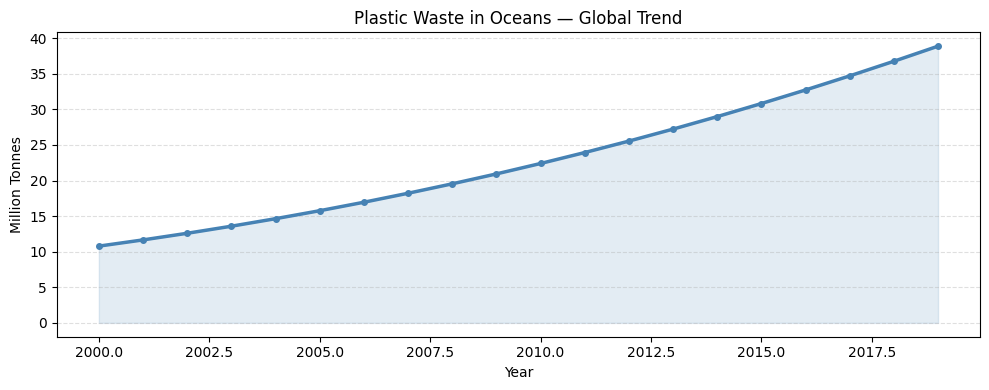

In [42]:
def plot_global_trend(regions_df: pd.DataFrame, countries_df: pd.DataFrame) -> None:
    """Plot total ocean plastic over time."""
    world = regions_df[regions_df["country"].str.lower() == "world"].sort_values("year")
    if world.empty:
        world = countries_df.groupby("year", as_index=False)["plastic_ocean_tonnes"].sum()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(world["year"], world["plastic_ocean_tonnes"] / 1e6,
            color="steelblue", linewidth=2.5, marker="o", markersize=4)
    ax.fill_between(world["year"], world["plastic_ocean_tonnes"] / 1e6, alpha=0.15, color="steelblue")
    ax.set_title("Plastic Waste in Oceans — Global Trend")
    ax.set_xlabel("Year"); ax.set_ylabel("Million Tonnes")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.show()

plot_global_trend(ocean_plastic_regions, ocean_plastic_countries)

8. save

In [43]:
def save_clean_parquet(df: pd.DataFrame, path: Path) -> None:
    #Save cleaned DataFrame as parquet.
    df.to_parquet(path, index=False)
    print(f"Saved → {path}  ({path.stat().st_size / 1024:.1f} KB, {len(df):,} rows)")

save_clean_parquet(
    ocean_plastic_countries,
    DATA_CLEAN / "ocean_plastic.parquet"
)

Saved → ..\Data\Clean\ocean_plastic.parquet  (5.5 KB, 80 rows)


### Sixt dataset:
plastic=waste-generation.csv


1. load

In [44]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)
plastic_generation = pd.read_csv(config["input_data"]["file6"])
plastic_generation.head(10)

,Entity,Code,Year,"Plastic waste generation (tonnes, total)"
0,Albania,ALB,2010,73364
1,Algeria,DZA,2010,1898343
2,Angola,AGO,2010,528843
3,Antigua and Barbuda,ATG,2010,22804
4,Argentina,ARG,2010,2753550
5,Aruba,ABW,2010,9352
6,Australia,AUS,2010,900658
7,Bahamas,BHS,2010,51364
8,Bahrain,BHR,2010,59785
9,Bangladesh,BGD,2010,1888170


In [45]:
inspect_dataframe(plastic_generation, "plastic_generation (raw)")


  plastic_generation (raw)  —  168 rows × 4 cols

── Columns ──
['Entity', 'Code', 'Year', 'Plastic waste generation (tonnes, total)']

── Dtypes ──
Entity                                      object
Code                                        object
Year                                         int64
Plastic waste generation (tonnes, total)     int64
dtype: object

── Null counts ──
                                          nulls  null_%
Entity                                        0     0.0
Code                                          0     0.0
Year                                          0     0.0
Plastic waste generation (tonnes, total)      0     0.0

── Stats ──
         Year  Plastic waste generation (tonnes, total)
count   168.0                              1.680000e+02
mean   2010.0                              1.626619e+06
std       0.0                              5.660377e+06
min    2010.0                              5.270000e+02
25%    2010.0                           

A few things stand out:

No nulls at all — nothing to fill or drop
Only one year: 2010 — std = 0, so year is essentially a constant, not useful for trend analysis. We'll keep it but worth flagging.
168 rows, all countries — no aggregate "World" rows since Code has 0 nulls

2. rename columns

In [46]:
def rename_plastic_generation_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names to snake_case."""
    df = df.copy()
    rename_map = {
        "Entity": "country",
        "Code":   "iso_code",
        "Year":   "year",
        "Plastic waste generation (tonnes, total)": "plastic_generation_tonnes",
    }
    df = df.rename(columns=rename_map)
    print("Columns after rename:", df.columns.tolist())
    return df

plastic_generation = rename_plastic_generation_columns(plastic_generation)
plastic_generation.head()

Columns after rename: ['country', 'iso_code', 'year', 'plastic_generation_tonnes']


,country,iso_code,year,plastic_generation_tonnes
0,Albania,ALB,2010,73364
1,Algeria,DZA,2010,1898343
2,Angola,AGO,2010,528843
3,Antigua and Barbuda,ATG,2010,22804
4,Argentina,ARG,2010,2753550


3. fix dtypes

In [47]:
def fix_dtypes_plastic_generation(df: pd.DataFrame) -> pd.DataFrame:
    """Cast to correct dtypes."""
    df = df.copy()
    df["year"]                      = df["year"].astype("Int64")
    df["plastic_generation_tonnes"] = df["plastic_generation_tonnes"].astype(float)
    df["country"]                   = df["country"].astype(str).str.strip()
    df["iso_code"]                  = df["iso_code"].astype(str).str.strip()
    print("Dtypes after fix:"); print(df.dtypes)
    return df

plastic_generation = fix_dtypes_plastic_generation(plastic_generation)

Dtypes after fix:
country                       object
iso_code                      object
year                           Int64
plastic_generation_tonnes    float64
dtype: object


4. remove duplicates

In [48]:
def remove_duplicates_plastic_generation(df: pd.DataFrame) -> pd.DataFrame:
    """Check and remove duplicate rows."""
    n_exact = df.duplicated().sum()
    print(f"Exact duplicates: {n_exact}")
    df = df.drop_duplicates()
    n_logical = df.duplicated(subset=["country", "year"]).sum()
    print(f"Logical duplicates on (country, year): {n_logical}")
    df = df.drop_duplicates(subset=["country", "year"], keep="first")
    print(f"Shape after dedup: {df.shape}")
    return df

plastic_generation = remove_duplicates_plastic_generation(plastic_generation)

Exact duplicates: 0
Logical duplicates on (country, year): 0
Shape after dedup: (168, 4)


5. add derived columns

In [49]:
def add_derived_columns_plastic_generation(df: pd.DataFrame) -> pd.DataFrame:
    """Add human-readable million tonnes column."""
    df = df.copy()
    df["plastic_generation_million_tonnes"] = (df["plastic_generation_tonnes"] / 1_000_000).round(4)
    return df

plastic_generation = add_derived_columns_plastic_generation(plastic_generation)
plastic_generation[["country", "year", "plastic_generation_tonnes", "plastic_generation_million_tonnes"]].head(10)

,country,year,plastic_generation_tonnes,plastic_generation_million_tonnes
0,Albania,2010,73364.0,0.0734
1,Algeria,2010,1898343.0,1.8983
2,Angola,2010,528843.0,0.5288
3,Antigua and Barbuda,2010,22804.0,0.0228
4,Argentina,2010,2753550.0,2.7536
5,Aruba,2010,9352.0,0.0094
6,Australia,2010,900658.0,0.9007
7,Bahamas,2010,51364.0,0.0514
8,Bahrain,2010,59785.0,0.0598
9,Bangladesh,2010,1888170.0,1.8882


6. sanity check

In [50]:
def sanity_check_plastic_generation(df: pd.DataFrame) -> None:
    """Check for negatives and show top 5 producers."""
    neg = (df["plastic_generation_tonnes"] < 0).sum()
    print(f"Negative values: {'none ✅' if neg == 0 else f'{neg} found ⚠️'}")
    print(f"Year range: {df['year'].min()} – {df['year'].max()}")
    print(f"Countries: {df['country'].nunique()}")
    print("\nTop 5 plastic producers:")
    print(
        df.nlargest(5, "plastic_generation_tonnes")[["country", "plastic_generation_tonnes"]]
          .to_string(index=False)
    )

sanity_check_plastic_generation(plastic_generation)

Negative values: none ✅
Year range: 2010 – 2010
Countries: 168

Top 5 plastic producers:
      country  plastic_generation_tonnes
        China                 59079741.0
United States                 37825550.0
      Germany                 14476561.0
       Brazil                 11852055.0
        Japan                  7993489.0


7. save

In [51]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)
save_clean_parquet(
    plastic_generation,
    Path(config["output_data"]["file6"])
)

Saved → ..\Data\Clean\plastic_generation.parquet  (8.9 KB, 168 rows)


### 7th dataset:
plastic-waste-vs-polution

1. load and check

In [52]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [53]:
plastic_vs_pollution = pd.read_csv(config["input_data"]["file7"])
plastic_vs_pollution.head(10)

,Entity,Code,Year,Plastic pollution per capita,Plastic waste generation per capita,World Bank's 2025 income classification
0,Afghanistan,AFG,2020,11.732275,22.118752,Low-income countries
1,Africa (UN M49),NaN,2020,11.463041,21.457820,NaN
2,Akrotiri and Dhekelia,OWID_AKD,2020,0.235398,70.455055,NaN
3,Aland Islands,ALA,2020,0.194135,64.888084,NaN
4,Albania,ALB,2020,7.770419,45.700294,Upper-middle-income countries
5,Algeria,DZA,2020,8.739351,33.999477,Upper-middle-income countries
6,American Samoa,ASM,2020,5.183191,43.086160,High-income countries
7,Americas (UN M49),NaN,2020,4.567344,53.564870,NaN
8,Andorra,AND,2020,0.149844,81.458570,High-income countries
9,Angola,AGO,2020,16.488740,29.233612,Lower-middle-income countries


 A few things stand out:
Again only one year: 2020 — snapshot data, good for per-capita comparisons in Q1
Code: 7 nulls (2.77%) — small, likely aggregate rows like "World"
World Bank income classification: 39 nulls (15.42%) — these will be the aggregate/region rows, we'll fill with "Unknown"
Two per-capita metrics — pollution vs generation, great for Q1 correlation analysis

2. rename columns

In [54]:
def rename_plastic_vs_pollution_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names to snake_case."""
    df = df.copy()
    rename_map = {
        "Entity":                                   "country",
        "Code":                                     "iso_code",
        "Year":                                     "year",
        "Plastic pollution per capita":             "plastic_pollution_per_capita",
        "Plastic waste generation per capita":      "plastic_generation_per_capita",
        "World Bank's 2025 income classification":  "income_group",
    }
    df = df.rename(columns=rename_map)
    print("Columns after rename:", df.columns.tolist())
    return df

plastic_vs_pollution = rename_plastic_vs_pollution_columns(plastic_vs_pollution)
plastic_vs_pollution.head()

Columns after rename: ['country', 'iso_code', 'year', 'plastic_pollution_per_capita', 'plastic_generation_per_capita', 'income_group']


,country,iso_code,year,plastic_pollution_per_capita,plastic_generation_per_capita,income_group
0,Afghanistan,AFG,2020,11.732275,22.118752,Low-income countries
1,Africa (UN M49),NaN,2020,11.463041,21.457820,NaN
2,Akrotiri and Dhekelia,OWID_AKD,2020,0.235398,70.455055,NaN
3,Aland Islands,ALA,2020,0.194135,64.888084,NaN
4,Albania,ALB,2020,7.770419,45.700294,Upper-middle-income countries


3. handle missing values

In [55]:
def handle_missing_plastic_vs_pollution(df: pd.DataFrame) -> pd.DataFrame:
    """Fill iso_code and income_group NaNs, nothing to drop."""
    df = df.copy()
    rows_before = len(df)

    df["iso_code"]     = df["iso_code"].fillna("REGION")
    df["income_group"] = df["income_group"].fillna("Unknown")

    print(f"Rows before: {rows_before} → after: {len(df)} (removed {rows_before - len(df)})")
    print(df.isnull().sum())
    return df

plastic_vs_pollution = handle_missing_plastic_vs_pollution(plastic_vs_pollution)

Rows before: 253 → after: 253 (removed 0)
country                          0
iso_code                         0
year                             0
plastic_pollution_per_capita     0
plastic_generation_per_capita    0
income_group                     0
dtype: int64


4. fix dtypes

In [56]:
def fix_dtypes_plastic_vs_pollution(df: pd.DataFrame) -> pd.DataFrame:
    """Cast to correct dtypes."""
    df = df.copy()
    df["year"]                          = df["year"].astype("Int64")
    df["plastic_pollution_per_capita"]  = df["plastic_pollution_per_capita"].astype(float)
    df["plastic_generation_per_capita"] = df["plastic_generation_per_capita"].astype(float)
    df["country"]                       = df["country"].astype(str).str.strip()
    df["iso_code"]                      = df["iso_code"].astype(str).str.strip()
    df["income_group"]                  = df["income_group"].astype(str).str.strip()
    print("Dtypes after fix:"); print(df.dtypes)
    return df

plastic_vs_pollution = fix_dtypes_plastic_vs_pollution(plastic_vs_pollution)

Dtypes after fix:
country                           object
iso_code                          object
year                               Int64
plastic_pollution_per_capita     float64
plastic_generation_per_capita    float64
income_group                      object
dtype: object


5. remove duplicates

In [57]:
def remove_duplicates_plastic_vs_pollution(df: pd.DataFrame) -> pd.DataFrame:
    """Check and remove duplicate rows."""
    n_exact = df.duplicated().sum()
    print(f"Exact duplicates: {n_exact}")
    df = df.drop_duplicates()
    n_logical = df.duplicated(subset=["country", "year"]).sum()
    print(f"Logical duplicates on (country, year): {n_logical}")
    df = df.drop_duplicates(subset=["country", "year"], keep="first")
    print(f"Shape after dedup: {df.shape}")
    return df

plastic_vs_pollution = remove_duplicates_plastic_vs_pollution(plastic_vs_pollution)

Exact duplicates: 0
Logical duplicates on (country, year): 0
Shape after dedup: (253, 6)


6. split countries vs regions

In [58]:
plastic_vs_pollution_countries, plastic_vs_pollution_regions = split_countries_and_regions(plastic_vs_pollution)
plastic_vs_pollution_countries.tail()

Countries: 246 rows, 246 unique
Regions  : 7 rows


,country,iso_code,year,plastic_pollution_per_capita,plastic_generation_per_capita,income_group
241,Western Sahara,ESH,2020,8.535897,28.840668,Unknown
242,World,OWID_WRL,2020,6.651020,33.124847,Unknown
243,Yemen,YEM,2020,10.140191,28.098106,Low-income countries
244,Zambia,ZMB,2020,11.374153,16.633657,Lower-middle-income countries
245,Zimbabwe,ZWE,2020,10.394113,13.585236,Lower-middle-income countries


7. sanity check

In [59]:
def sanity_check_plastic_vs_pollution(df: pd.DataFrame) -> None:
    """Check negatives, income group distribution, top polluters."""
    for col in ["plastic_pollution_per_capita", "plastic_generation_per_capita"]:
        neg = (df[col] < 0).sum()
        print(f"Negative values in {col}: {'none ✅' if neg == 0 else f'{neg} ⚠️'}")

    print(f"\nIncome group distribution:")
    print(df["income_group"].value_counts().to_string())

    print(f"\nTop 5 by plastic pollution per capita:")
    print(
        df.nlargest(5, "plastic_pollution_per_capita")[["country", "plastic_pollution_per_capita", "income_group"]]
          .to_string(index=False)
    )

sanity_check_plastic_vs_pollution(plastic_vs_pollution_countries)

Negative values in plastic_pollution_per_capita: none ✅
Negative values in plastic_generation_per_capita: none ✅

Income group distribution:
income_group
High-income countries            87
Upper-middle-income countries    52
Lower-middle-income countries    50
Unknown                          32
Low-income countries             25

Top 5 by plastic pollution per capita:
          country  plastic_pollution_per_capita                  income_group
         Cambodia                     25.237030 Lower-middle-income countries
         Paraguay                     23.352188 Upper-middle-income countries
Equatorial Guinea                     20.775099 Upper-middle-income countries
      South Sudan                     20.366692          Low-income countries
            Haiti                     20.326550 Lower-middle-income countries


8. save

In [60]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

save_clean_parquet(
    plastic_vs_pollution_countries,
    Path(config["output_data"]["file7"])
)

Saved → ..\Data\Clean\plastic_vs_pollution.parquet  (12.8 KB, 246 rows)


Seventh dataset:
Cleanup efforts from The Ocean cleanup and ICC (Ocean Conservancy)
This one I need to create because the dataset is not available.
I could not scrape because The dashboard data is rendered dynamically via JavaScript

1. create dataset The Ocean Cleunup

In [61]:
toc_data = {
    "year":         [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "kg_removed":   [103000, 397000, 500000, 2000000, 8000000, 7000000, 10000000],
    "organisation": "The Ocean Cleanup",
    "cleanup_type": "Ocean + River",
    "source_url":   "https://theoceancleanup.com/milestones"
}

toc_df = pd.DataFrame(toc_data)
toc_df["kg_removed_annual"]     = toc_df["kg_removed"]
toc_df["kg_removed_cumulative"] = toc_df["kg_removed"].cumsum()
toc_df = toc_df.drop(columns=["kg_removed"])
print(toc_df)

   year       organisation   cleanup_type  \
0  2019  The Ocean Cleanup  Ocean + River   
1  2020  The Ocean Cleanup  Ocean + River   
2  2021  The Ocean Cleanup  Ocean + River   
3  2022  The Ocean Cleanup  Ocean + River   
4  2023  The Ocean Cleanup  Ocean + River   
5  2024  The Ocean Cleanup  Ocean + River   
6  2025  The Ocean Cleanup  Ocean + River   

                               source_url  kg_removed_annual  \
0  https://theoceancleanup.com/milestones             103000   
1  https://theoceancleanup.com/milestones             397000   
2  https://theoceancleanup.com/milestones             500000   
3  https://theoceancleanup.com/milestones            2000000   
4  https://theoceancleanup.com/milestones            8000000   
5  https://theoceancleanup.com/milestones            7000000   
6  https://theoceancleanup.com/milestones           10000000   

   kg_removed_cumulative  
0                 103000  
1                 500000  
2                1000000  
3                3

2. create dataset ICC (Ocean conservancy)

In [62]:
# Source: Ocean Conservancy ICC Annual Reports 1986–2025
# kg converted from lbs where needed (1 lb = 0.453592 kg)
# Volunteers and countries from report cover pages

icc_data = {
    "year": list(range(2008, 2026)),
    "volunteers": [
        378000, 408000, 520000, 519000, 560000, 648000,
        561000, 788000, 800000, 892000, 704000, 530000,
        630000, 486000, 486000, 550000, 486000, 500000
    ],
    "kg_removed": [
        # converted from published lbs figures
        round(x * 0.453592) for x in [
            7200000, 7600000, 8000000, 9200000, 10200000, 12400000,
            10100000, 18400000, 18600000, 23600000, 19700000, 9100000,
            16800000, 8000000, 7900000, 8200000, 7400000, 8000000
        ]
    ],
    "countries": [
        104, 108, 108, 112, 151, 153,
        91, 112, 112, 122, 112, 80,
        100, 116, 116, 120, 120, 125
    ],
    "organisation": "Ocean Conservancy (ICC)",
    "cleanup_type": "Beach + Waterway",
    "source_url": "https://oceanconservancy.org/work/plastics/cleanups-icc/annual-data-release/"
}

icc_df = pd.DataFrame(icc_data)
icc_df["kg_removed_annual"] = icc_df["kg_removed"]
icc_df["kg_removed_cumulative"] = icc_df["kg_removed"].cumsum()
icc_df = icc_df.drop(columns=["kg_removed"])
print(icc_df)

    year  volunteers  countries             organisation      cleanup_type  \
0   2008      378000        104  Ocean Conservancy (ICC)  Beach + Waterway   
1   2009      408000        108  Ocean Conservancy (ICC)  Beach + Waterway   
2   2010      520000        108  Ocean Conservancy (ICC)  Beach + Waterway   
3   2011      519000        112  Ocean Conservancy (ICC)  Beach + Waterway   
4   2012      560000        151  Ocean Conservancy (ICC)  Beach + Waterway   
5   2013      648000        153  Ocean Conservancy (ICC)  Beach + Waterway   
6   2014      561000         91  Ocean Conservancy (ICC)  Beach + Waterway   
7   2015      788000        112  Ocean Conservancy (ICC)  Beach + Waterway   
8   2016      800000        112  Ocean Conservancy (ICC)  Beach + Waterway   
9   2017      892000        122  Ocean Conservancy (ICC)  Beach + Waterway   
10  2018      704000        112  Ocean Conservancy (ICC)  Beach + Waterway   
11  2019      530000         80  Ocean Conservancy (ICC)  Beach 

3. combine into 1 data set

In [63]:
def combine_cleanup_efforts(toc_df: pd.DataFrame, icc_df: pd.DataFrame) -> pd.DataFrame:
    """
    Combine The Ocean Cleanup and ICC datasets into one
    unified cleanup_efforts DataFrame.

    Keeps each organisation as a separate row per year so
    you can compare them or aggregate as needed.
    """
    # Align columns — ICC has volunteers/countries, TOC does not
    combined = pd.concat([toc_df, icc_df], ignore_index=True)
    combined = combined.sort_values(["year", "organisation"]).reset_index(drop=True)

    # Fill missing volunteer/country columns for TOC rows
    combined["volunteers"] = combined["volunteers"].fillna(0).astype(int)
    combined["countries"]  = combined["countries"].fillna(0).astype(int)

    print(f"Shape: {combined.shape}")
    print(f"\nOrganisations: {combined['organisation'].unique()}")
    print(f"Year range   : {combined['year'].min()} – {combined['year'].max()}")
    return combined

cleanup_efforts = combine_cleanup_efforts(toc_df, icc_df)
cleanup_efforts.head()

Shape: (25, 8)

Organisations: ['Ocean Conservancy (ICC)' 'The Ocean Cleanup']
Year range   : 2008 – 2025


,year,organisation,cleanup_type,source_url,kg_removed_annual,kg_removed_cumulative,volunteers,countries
0,2008,Ocean Conservancy (ICC),Beach + Waterway,https://oceanconservancy.org/work/plastics/cle...,3265862,3265862,378000,104
1,2009,Ocean Conservancy (ICC),Beach + Waterway,https://oceanconservancy.org/work/plastics/cle...,3447299,6713161,408000,108
2,2010,Ocean Conservancy (ICC),Beach + Waterway,https://oceanconservancy.org/work/plastics/cle...,3628736,10341897,520000,108
3,2011,Ocean Conservancy (ICC),Beach + Waterway,https://oceanconservancy.org/work/plastics/cle...,4173046,14514943,519000,112
4,2012,Ocean Conservancy (ICC),Beach + Waterway,https://oceanconservancy.org/work/plastics/cle...,4626638,19141581,560000,151


4. sanity check

In [64]:
def sanity_check_cleanup_efforts(df: pd.DataFrame) -> None:
    """Check for negatives and print summary per organisation."""
    neg = (df["kg_removed_annual"] < 0).sum()
    print(f"Negative kg values: {'none ✅' if neg == 0 else f'{neg} ⚠️'}")

    print("\nTotal kg removed per organisation:")
    print(
        df.groupby("organisation")["kg_removed_annual"]
          .sum()
          .apply(lambda x: f"{x:,.0f} kg")
          .to_string()
    )

    print("\nRows per organisation:")
    print(df["organisation"].value_counts().to_string())

sanity_check_cleanup_efforts(cleanup_efforts)

Negative kg values: none ✅

Total kg removed per organisation:
organisation
Ocean Conservancy (ICC)    95,435,755 kg
The Ocean Cleanup          28,000,000 kg

Rows per organisation:
organisation
Ocean Conservancy (ICC)    18
The Ocean Cleanup           7


5. save

In [65]:
# Save raw version too so it's traceable
raw_path = Path("../Data/Raw/ocean_cleanup_efforts.csv")
cleanup_efforts.to_csv(raw_path, index=False)
print(f"Raw CSV saved → {raw_path}")

# Reload config and save clean parquet
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

save_clean_parquet(
    cleanup_efforts,
    Path(config["output_data"]["file8"])
)

Raw CSV saved → ..\Data\Raw\ocean_cleanup_efforts.csv
Saved → ..\Data\Clean\ocean_cleanup_efforts.parquet  (6.2 KB, 25 rows)


In [66]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

rivers_with_countries = pd.read_parquet(config["output_data"]["file1"])
rivers_with_countries.head(5)

,emission,geometry,country,continent
0,0.164904,b'\x01\x01\x00\x00\x008\x87\x88\x88\x88\x19e@ ...,New Zealand,Oceania
1,0.124932,b'\x01\x01\x00\x00\x00\x0c\x8e\xc2\xf5(\x0be@p...,New Zealand,Oceania
2,1.213370,b'\x01\x01\x00\x00\x00\xe8\x94\xfcb\xc9\ne@\xd...,New Zealand,Oceania
3,0.121138,b'\x01\x01\x00\x00\x00\xf8\xdfz\x14\xae\x00e@\...,New Zealand,Oceania
4,0.197533,b'\x01\x01\x00\x00\x00\xdcZ\x8f\xc2\xf59e@\x18...,New Zealand,Oceania


In [67]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

rivers_with_countries = gpd.read_parquet(config["output_data"]["file1"])
rivers_with_countries.head(5)

,emission,geometry,country,continent
0,0.164904,POINT (168.79792 -46.58083),New Zealand,Oceania
1,0.124932,POINT (168.34875 -46.44708),New Zealand,Oceania
2,1.213370,POINT (168.33708 -46.41875),New Zealand,Oceania
3,0.121138,POINT (168.02125 -46.35792),New Zealand,Oceania
4,0.197533,POINT (169.81125 -46.34375),New Zealand,Oceania


### Eight dataset:

1. load and create df

In [68]:
rivers_ranked = []

with pdfplumber.open("../Data/Raw/aaz5803_sm.pdf") as pdf:
    for i in range(20, 30):  # extend to page 30
        page = pdf.pages[i]
        text = page.extract_text()
        if text:
            for line in text.split('\n'):
                parts = line.strip().split()
                if parts and parts[0].isdigit():
                    match = re.match(r'^(\d+)\s+(.+?)\s+(\S+)\s+([\d.E+]+)\s+', line.strip())
                    if match and int(match.group(1)) <= 1000:  # only keep river rankings
                        rivers_ranked.append({
                            'ranking': match.group(1),
                            'river_name': match.group(2),
                            'country': match.group(3),
                            'emission_tons_year': match.group(4)
                        })

df_rivers = pd.DataFrame(rivers_ranked)
df_rivers = df_rivers.drop_duplicates(subset='ranking')
print(df_rivers.shape)
print(df_rivers.tail(20))

(51, 4)
   ranking                  river_name      country emission_tons_year
31      32              Cagayan de Oro  Philippines            2.6E+03
32      33                 Davao River  Philippines            2.6E+03
33      34                  Karnaphuli   Bangladesh            2.6E+03
34      35                  Rio Pavuna       Brazil            2.6E+03
35      36                Panvel Creek        India            2.5E+03
36      37                Yangon River      Myanmar            2.5E+03
37      38              Malaking Tubig  Philippines            2.5E+03
38      39             Zhujiang/Canton        China            2.5E+03
39      40  Tambo, Pasay (Storm drain)  Philippines            2.5E+03
40      41              Kelantan River     Malaysia            2.5E+03
41      42                Jalaur River  Philippines            2.3E+03
42      43              Douala Estuary     Cameroon            2.3E+03
43      44               Chilyar River        India            2.3E+0

2. fix parsing errors

In [69]:
# Manual fixes for known parsing errors
fixes = {
    '23': ('Msimbazi River', 'Tanzania'),  # Dar Es Salaam is a city, not a country
    '49': ('Rio Ozama', 'Dominican Republic'),
    '21': ('Ebrie Lagoon / Komoe', 'Ivory Coast'),
}

for ranking, (river, country) in fixes.items():
    df_rivers.loc[df_rivers['ranking'] == ranking, 'river_name'] = river
    df_rivers.loc[df_rivers['ranking'] == ranking, 'country'] = country

# Drop the junk row
df_rivers = df_rivers[df_rivers['ranking'].astype(int) <= 50]
df_rivers['ranking'] = df_rivers['ranking'].astype(int)
df_rivers['emission_tons_year'] = df_rivers['emission_tons_year'].astype(float)

print(df_rivers.shape)
display(df_rivers.head())

(50, 4)


,ranking,river_name,country,emission_tons_year
0,1,Pasig,Philippines,63000.0
1,2,Tullahan,Philippines,13000.0
2,3,Ulhas,India,13000.0
3,4,Klang,Malaysia,13000.0
4,5,Meycauayan,Philippines,12000.0


3. save

In [70]:
#df_rivers.to_parquet("../Data/Clean/top50_rivers_ranked.parquet", index=False)

### Nineth dataset:
"pnas.2415492122.sd01.csv" as species

In [74]:
species = pd.read_csv(
    config["input_data"]["file9"],
    encoding="latin1",
    low_memory=False
)

In [75]:
# Clean column names properly
species.columns = (
    species.columns
    .str.encode("ascii", "ignore")
    .str.decode("ascii")
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

In [78]:
# Rename for sanity
species = species.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})

In [79]:
species["lat"] = pd.to_numeric(species["lat"], errors="coerce")
species["lon"] = pd.to_numeric(species["lon"], errors="coerce")

species = species.dropna(subset=["lat", "lon"])

species = species[
    (species["lat"].between(-90, 90)) &
    (species["lon"].between(-180, 180))
]

In [80]:
plastic_cols = [col for col in species.columns if any(x in col for x in [
    "pellet", "fragment", "foam", "film",
    "line", "rope", "net", "rubber"
])]

species[plastic_cols] = species[plastic_cols].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

In [81]:
species["has_plastic"] = (species[plastic_cols].sum(axis=1) > 0).astype(int)
species["plastic_count"] = species[plastic_cols].sum(axis=1)

In [82]:
species.to_parquet("../Data/Clean/species", index=False)

In [ ]:
print(species.shape)
species.head()
species.info()


(10205, 111)
<class 'pandas.core.frame.DataFrame'>
Index: 10205 entries, 0 to 10411
Columns: 111 entries, citation to plastic_count
dtypes: float64(70), int64(11), object(30)
memory usage: 8.7+ MB
-53.0 78.38
-178.0 180.0


In [ ]:
print(species["lat"].min(), species["lat"].max())
print(species["lon"].min(), species["lon"].max())

-53.0 78.38
-178.0 180.0


In [88]:
species.isna().sum().sort_values(ascending=False).head(15)

obstruction_or_perforation?    10117
git_location                   10115
item_spec                      10072
item_gen                        9707
vol_calculation_see_smfig1      9339
notes                           9143
death                           6775
sex                             3644
size                            3558
age                             2136
lid_volume                      1838
bottle_volume                   1836
bag_volume                      1831
lure_volume                     1824
mass                            1146
dtype: int64

In [89]:
import plotly.express as px

fig = px.scatter_geo(
    species.sample(2000),  # sample for speed
    lat="lat",
    lon="lon",
    title="Sample of Species Locations"
)

fig.show()

In [90]:
species["has_plastic"].value_counts(normalize=True)

has_plastic
0    0.874865
1    0.125135
Name: proportion, dtype: float64

In [91]:
species["plastic_count"].describe()

count    10205.000000
mean        24.168992
std        837.060971
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      76473.421050
Name: plastic_count, dtype: float64

In [92]:
species[plastic_cols].sum().sort_values(ascending=False).head(10)

net_volume              115864.573614
line_length              20624.006000
line_volume              17814.508835
line_1_cross_section     16703.850000
film_1_cross_section     14300.171006
rope_1_cross_section     10062.200000
rope_volume               8300.524541
line_2_cross_section      7077.910000
film_2_cross_section      6919.250318
film_3_cross_section      5961.173125
dtype: float64

species/ group sanity

In [93]:
species["group"].value_counts().head(10)

group
Manatee          4950
Toothed Whale    1386
Turtle           1239
Pinniped         1213
Shearwater        461
Prion             374
Albatross         283
Penguin            43
Tern               39
Guillemot          30
Name: count, dtype: int64

Duplicate check

In [94]:
species.duplicated().sum()

np.int64(869)

In [95]:
species[species.duplicated()].head()

,citation,id,taxa,group,species,family,age,size,size_avg,size_age,...,line_2_cross_section,line_3_cross_section,rope_1_cross_section,rope_2_cross_section,rope_3_cross_section,rubber_1_cross_section,rubber_2_cross_section,net_cross_section,has_plastic,plastic_count
47,Di Beneditto and Oliveira et al. 2019,NaN,Mammal,Toothed Whale,La Plata Dolphin,Delphinidae,NaN,NaN,29.0,108.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
48,Di Beneditto and Oliveira et al. 2019,NaN,Mammal,Toothed Whale,La Plata Dolphin,Delphinidae,NaN,NaN,29.0,108.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
49,Di Beneditto and Oliveira et al. 2019,NaN,Mammal,Toothed Whale,La Plata Dolphin,Delphinidae,NaN,NaN,29.0,108.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
50,Di Beneditto and Oliveira et al. 2019,NaN,Mammal,Toothed Whale,La Plata Dolphin,Delphinidae,NaN,NaN,29.0,108.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
51,Di Beneditto and Oliveira et al. 2019,NaN,Mammal,Toothed Whale,La Plata Dolphin,Delphinidae,NaN,NaN,29.0,108.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0


ourlier check

In [96]:
species.nlargest(5, "plastic_count")[["species", "plastic_count"]]

,species,plastic_count
8659,Sperm Whale,76473.421050
8658,Sperm Whale,24932.684211
6881,Sperm Whale,19001.000000
8662,Bottlenose Dolphin,12277.027475
6880,Sperm Whale,6889.152000


coverage check